In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Mathematical exercises

**Exercise 1** (4 points): Problem 13.5 in the PRML textbook.

**Exercise 2** (2 points): Problem 13.6 in the PRML textbook.

**Exercise 3** (4 points): Use the two basic rules of probability (the "sum and product rules" from PRML Chapter 2) to prove the following for an HMM (PRML Eq. (13.24)):
$
p(\mathbf{X}|\mathbf{z}_n) = p(\mathbf{x}_1, \ldots, \mathbf{x}_n | \mathbf{z}_n)
p(\mathbf{x}_{n+1}, \ldots, \mathbf{x}_N | \mathbf{z}_n).
$

# Coding exercises

In this notebook we will create some synthetic data and fit it with a hidden Markov model.

To begin, we will generate a synthetic time series of data. The latent variable `z` in our model will be binary, where `z[n]=0` corresponds to the first latent state at timestep `n`, and `z[n]=1` corresponds to the other latent state. The transition probabilities between `z[n]` and `z[n+1]` are described by the 2x2 matrix `trans_prob`. At each `n`, an observation `x[n]` is drawn from a normal distribution with mean and covariance `(m1, s1)` (if `z[n]=0`) or `(m2, s2)` (if `z[n]=1`).

The block of code below defines the parameters for our generating model. We will later try to estimate these parameters given the observations `x`.

In [2]:
# Means and covariances for the two Gaussian emission distributions:
m1 = np.array([1,1])
m2 = np.array([-1,-1])
m = [m1, m2]
# s1 = 0.5*np.eye([1,2],[1,2])
s1 = 0.5*np.eye(2)
s2 = 0.5*np.eye(2)
s = [s1, s2]

# trans_prob[i,j] is the probability of transitioning from state i to state j:
trans_prob = np.array([[0.8, 0.2], [0.1, 0.9]])
#trans_prob = np.array([[0.5, 0.5], [0.5, 0.5]])

**Exercise 1** (4 points): Using the parameters defined above, generate synthetic data `z` (a 1D array of length `n_steps`) and `x` (A 2D array of shape `n_steps` by 2, where 2 is the dimensionality of each observation). Make a plot of each of these variables.

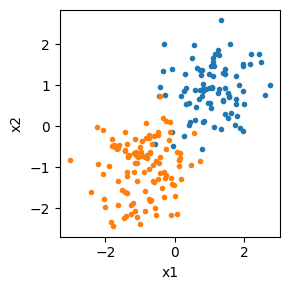

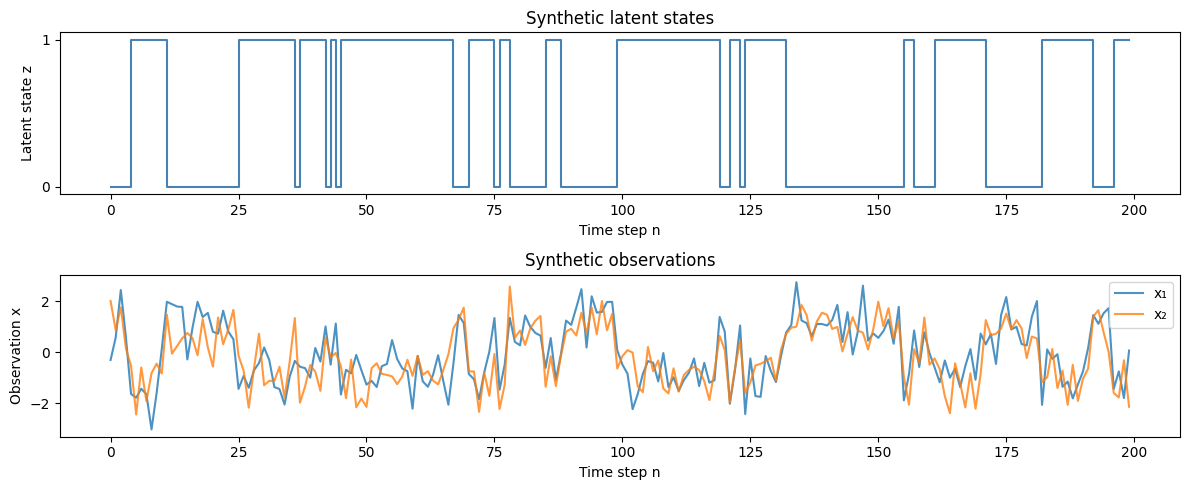

In [ ]:
## Solution ##
n_steps = 200


# Generate the synthetic data:
z = np.zeros(n_steps)  # latent states (0 or 1)
state = 0  # the initial state
x = np.zeros((n_steps, 2))  # observations
x[0] = np.random.multivariate_normal(m1, s1)  # initial observation
for nn in range(1, n_steps):
    state = np.random.choice(2, p=trans_prob[state])
    z[nn] = state
    x[nn,:] = np.random.multivariate_normal(m[state], s[state])

plt.figure(figsize=(3,3))
plt.plot(x[z==0,0], x[z==0,1], '.')
plt.plot(x[z==1,0], x[z==1,1], '.')
plt.xlabel('x1')
plt.ylabel('x2')
plt.tight_layout()

# Plot latent states (step plot) and observations (time series)
fig, axes = plt.subplots(2, 1, figsize=(12, 5))

axes[0].plot(z, drawstyle='steps-post', color='steelblue')
axes[0].set_ylabel('Latent state z')
axes[0].set_xlabel('Time step n')
axes[0].set_title('Synthetic latent states')
axes[0].set_yticks([0, 1])

axes[1].plot(x[:, 0], label='x₁', alpha=0.8)
axes[1].plot(x[:, 1], label='x₂', alpha=0.8)
axes[1].set_ylabel('Observation x')
axes[1].set_xlabel('Time step n')
axes[1].set_title('Synthetic observations')
axes[1].legend()

plt.tight_layout()
plt.show()




Our goal now will be to pretend that we don't know the parameters or latent states and infer these using a hidden Markov model. We'll use the `hmmlearn` package, which you may need to install before proceeding. To install the package, try running `pip install hmmlearn` in the terminal, or read the documentation here: https://github.com/hmmlearn/hmmlearn.

Let's import the package we'll need and read the documentation for `GaussianHMM`, a class which fits an HMM to data assuming Gaussian emissions.

In [4]:
from hmmlearn import hmm

hmm.GaussianHMM?

Init signature:
hmm.GaussianHMM(
    n_components=1,
    covariance_type='diag',
    min_covar=0.001,
    startprob_prior=1.0,
    transmat_prior=1.0,
    means_prior=0,
    means_weight=0,
    covars_prior=0.01,
    covars_weight=1,
    algorithm='viterbi',
    random_state=None,
    n_iter=10,
    tol=0.01,
    verbose=False,
    params='stmc',
    init_params='stmc',
    implementation='log',
)
Docstring:     
Hidden Markov Model with Gaussian emissions.

Attributes
----------
n_features : int
    Dimensionality of the Gaussian emissions.

monitor_ : ConvergenceMonitor
    Monitor object used to check the convergence of EM.

startprob_ : array, shape (n_components, )
    Initial state occupation distribution.

transmat_ : array, shape (n_components, n_components)
    Matrix of transition probabilities between states.

means_ : array, shape (n_components, n_features)
    Mean parameters for each state.

covars_ : array
    Covariance parameters for each state.

    The shape depends 

**Exercise 2** (4 points): Follow the example given at the following link to fit the data with an HMM, assuming two latent states (`n_components=2`):
https://hmmlearn.readthedocs.io/en/stable/tutorial.html#training-hmm-parameters-and-inferring-the-hidden-states

Compute the sequence of latent states inferred by the model, calling this `z_pred`, and compare this to the true sequence of hidden states by computing the correlation coefficient:
$$
\rho = \frac{\frac{1}{N}\sum_{n=1}^N(z_n - E(z)) (z^\mathrm{pred}_n - E(z^\mathrm{pred}))}
{\sqrt{\mathrm{Var}[z] \mathrm{Var}[z^\mathrm{pred}]}}.
$$
To check that your result makes sense, also print the model parameters (means and covariance matrices for the two hidden states, as well as the transition probability matrix) and show that they are similar (hopefully to within ~10% or so) to the parameters from the model that generated the data.

In [36]:
## Solution ##
model = hmm.GaussianHMM(n_components=2, covariance_type='full', n_iter=1000)
model.fit(x)
z_pred = model.predict(x)
print("Predicted latent states:\n", z_pred)

# switch to 0 and 1 
if (np.mean(z_pred) > 0.5):
    z_pred = 1 - z_pred

z_pred = np.abs(1-z_pred)

Predicted latent states:
 [0 0 0 0 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 1 1 1 1
 1 1 1 1 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1 1
 1 1 1 1 1 1 1 0 0 0 0 1 1 1 1]


In [35]:


# Compute the correlation coefficient:
rho = np.mean((z - np.mean(z))*(z_pred - np.mean(z_pred)))/(np.std(z)*np.std(z_pred))
print('Correlation coefficient: ', rho)
print('Easier version: ', np.corrcoef(z, z_pred)[0,1])

Correlation coefficient:  0.9115668762066473
Easier version:  0.9115668762066474


In [31]:
z_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
       0, 0])

In [32]:
z

array([0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 0., 1., 1., 1., 1., 1., 0., 1., 0., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0.,
       0., 0., 1., 1., 1., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0.,
       1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       0., 0., 1., 1., 0., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 1., 1., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 0., 0., 0., 0., 1., 1., 1., 1.])

In [ ]:
model = hmm.GaussianHMM(n_components=2, covariance_type='full', n_iter=1000)

In [6]:
# Compare the true and estimated parameters:

print('\n Estimated covariance matrices: \n', model.covars_)
print('\n True covariance matrices: \n', s1, s2)

print('\n Estimated observation means: \n', model.means_)
print('\n True observation means: \n', m1, m2)

print('\n Estimated transition probabilities: \n', model.transmat_)
print('\n True transition probabilities: \n', trans_prob)


 Estimated covariance matrices: 
 [[[ 0.48537807 -0.03042929]
  [-0.03042929  0.5194233 ]]

 [[ 0.41369988 -0.04452428]
  [-0.04452428  0.66117022]]]

 True covariance matrices: 
 [[0.5 0. ]
 [0.  0.5]] [[0.5 0. ]
 [0.  0.5]]

 Estimated observation means: 
 [[-1.0500736  -0.90284569]
 [ 1.06310332  1.00224899]]

 True observation means: 
 [1 1] [-1 -1]

 Estimated transition probabilities: 
 [[0.86928593 0.13071407]
 [0.17868748 0.82131252]]

 True transition probabilities: 
 [[0.8 0.2]
 [0.1 0.9]]


**Exercise 3** (5 points): **Detecting Financial Market Regimes**
This exercise applies the concepts of Hidden Markov Models to financial time series. It demonstrates a massive real-world advantage of HMMs over simpler clustering methods (like K-Means): the ability to model **persistence** (i.e., if the market is volatile today, it is likely to be volatile tomorrow).
In finance, stock markets are often described as having distinct "regimes" (e.g., a "Bull market" with steady growth and low volatility, or a "Bear/Crash market" with negative returns and high volatility). Because we cannot directly observe the "state" of the market mechanism, this is a perfect application for HMMs.

As usual, responsible AI use is encouraged in this last exercise, e.g. using AI as a tutor explaining the theory or helping to implement parts you aren't sure about or debug implementations. Optionally, you may include a brief reflection on how you used AI and what you learned from the interaction.

1.  **Data Acquisition:** Use the `yfinance` library (install via `pip install yfinance` if needed) to download the daily closing prices for the **S&P 500 ETF (Ticker: "SPY")** from **Jan 1, 2005 to Jan 1, 2015**. This period covers the 2008 Housing Crisis, providing a clear "high volatility" regime to detect.
2.  **Preprocessing:** HMMs usually require stationary data. Calculate the **daily log-returns**: $r_t = \ln(P_t) - \ln(P_{t-1})$. Reshape this data to be 2D: `(N_samples, 1)`.
3.  **Model Fitting:** Fit a `GaussianHMM` with **3 components** (hidden states) to the **log-returns**. (We use 3 states to capture Low, Medium, and High volatility regimes).
4.  **Analysis:**
    *   Print the variances (`covars_`) of the three fitted states. Identify which state index corresponds to the "High Volatility" regime (the state with the largest variance).
    *   Use the `predict` method to infer the sequence of hidden states.
5.  **Visualization:** Plot the raw stock price (the original Price history, *not* the returns) over the 10-year period. Overlay colored regions (using `axvspan` or scatter plot colors) to indicate which latent regime the market was in at that time. Does the "High Volatility" state align with the 2008 financial crash?

In [30]:
import yfinance as yf

ticker = yf.Ticker("SPY")
spy_data = ticker.history(start="2005-01-01", end="2015-01-01")

prices = spy_data["Close"].values
dates = spy_data.index

print(len(prices))
print(dates[0].date(), dates[-1].date())
print(prices.min(), prices.max())


2517
2005-01-03 2014-12-31
49.944580078125 173.3216094970703


In [ ]:

log_returns = np.diff(np.log(prices))  # r_t = ln(P_t) - ln(P_{t-1})

#(N_samples, 1) as required by hmmlearn
log_returns_2d = log_returns.reshape(-1, 1)

print(len(log_returns))
print(log_returns_2d.shape)
print(log_returns.mean(), log_returns.std())


2516
(2516, 1)
0.0002932802280966291 0.012814769760239363


In [21]:
from hmmlearn.hmm import GaussianHMM

hmm_model = GaussianHMM(n_components=3, covariance_type="full", n_iter=1000, random_state=42)
hmm_model.fit(log_returns_2d)

print(hmm_model.monitor_.converged)
print(f"Number of hidden states: {hmm_model.n_components}")


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
Model is not converging.  Current: 8079.23173398846 is not greater than 8079.23884337381. Delta is -0.00710938534939487


True
Number of hidden states: 3


In [22]:
variances = hmm_model.covars_.squeeze()
sorted_states = np.argsort(variances)  
regime_names = {sorted_states[0]: "Low Volatility", sorted_states[1]: "Medium Volatility", sorted_states[2]: "High Volatility"}

# predict the sequence of hidden states from the log-returns
hidden_states = hmm_model.predict(log_returns_2d)
total = len(hidden_states)

for state_idx in sorted_states:
    print(f"  {regime_names[state_idx]}: variance = {variances[state_idx]:.8f}")
    count = (hidden_states == state_idx).sum()
    print(f"  {count} days ({100 * count / total:.1f}%)")


  Low Volatility: variance = 0.00005017
  1970 days (78.3%)
  Medium Volatility: variance = 0.00021975
  121 days (4.8%)
  High Volatility: variance = 0.00079529
  425 days (16.9%)


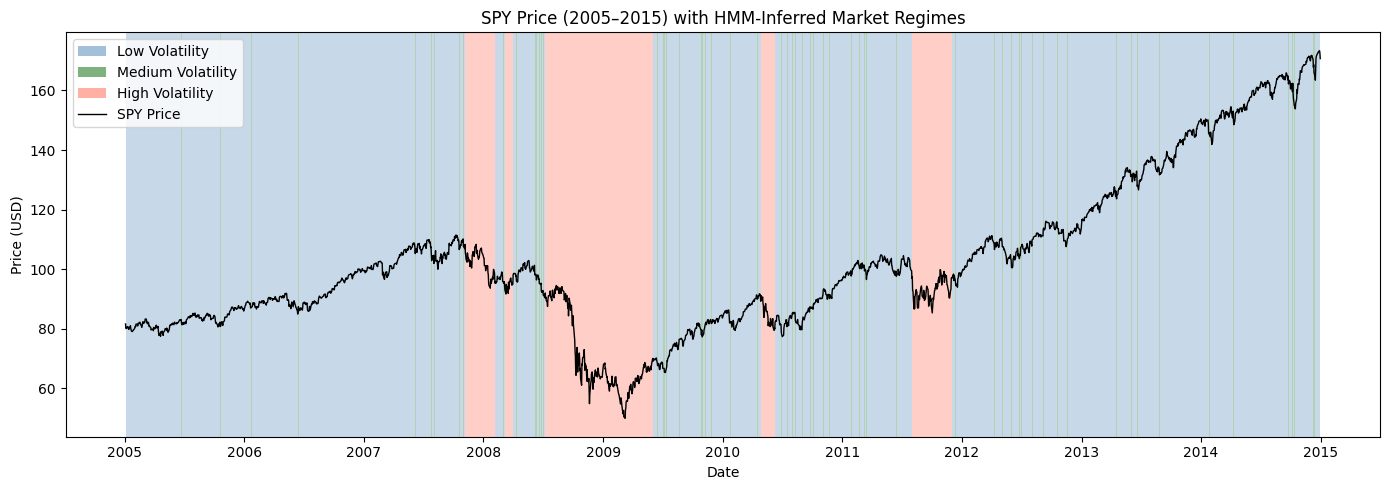

In [24]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch


variances = hmm_model.covars_.squeeze()
sorted_states = np.argsort(variances)  # sorted low → high variance
state_labels = {sorted_states[0]: "Low Volatility", sorted_states[1]: "Medium Volatility", sorted_states[2]: "High Volatility"}
state_colors = {sorted_states[0]: "steelblue", sorted_states[1]: "darkgreen", sorted_states[2]: "tomato"}

return_dates = dates[1:]

fig, ax = plt.subplots(figsize=(14, 5))

i = 0
while i < len(hidden_states):
    current_state = hidden_states[i]
    j = i
    while j < len(hidden_states) and hidden_states[j] == current_state:
        j += 1
    end_date = return_dates[j] if j < len(return_dates) else return_dates[-1]
    ax.axvspan(return_dates[i], end_date, alpha=0.3,
               color=state_colors[current_state], lw=0)
    i = j

ax.plot(dates, prices, color="black", linewidth=1, label="SPY Close Price")

legend_elements = [Patch(facecolor=state_colors[s], alpha=0.5, label=state_labels[s])
                   for s in sorted(state_colors)]
legend_elements.append(plt.Line2D([0], [0], color="black", linewidth=1, label="SPY Price"))
ax.legend(handles=legend_elements, loc="upper left")

ax.set_title("SPY Price (2005–2015) with HMM-Inferred Market Regimes")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.tight_layout()
plt.show()


Yes it seems that the high volatility state aligns well with the 2008 financial crash and the following recession in 2009. The medium volatility (green) is sparse but mostly more common in between states of high volatility